In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [3]:
RUN = ["3"]
#RUN = ["1","2","3"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=True,
    loadnumuvariables=True,
    use_bdt=False,
    load_lee=False,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3


## Find out what's in dataframes

In [6]:
print(rundata.keys())
rundata['mc'].loc[:, ('elec_e')].head(60)
#print("category_1e1p" in rundata["mc"].columns)  #Prints true/false if variable exists in dataframe

dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])


entry
0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    0.0
27    0.0
28    0.0
29    0.0
30    0.0
31    0.0
32    0.0
33    0.0
34    0.0
35    0.0
36    0.0
37    0.0
38    0.0
39    0.0
40    0.0
41    0.0
42    0.0
43    0.0
44    0.0
45    0.0
46    0.0
47    0.0
48    0.0
49    0.0
50    0.0
52    0.0
53    0.0
54    0.0
55    0.0
56    0.0
57    0.0
58    0.0
59    0.0
60    0.0
Name: elec_e, dtype: float32

## Shows variables in dataframe (column = variable name)

In [1]:
for col in rundata['mc'].columns:
    print(col)

NameError: name 'rundata' is not defined

#### List of Possible variables for track length and mass

shr_tkfit_nhits_Y
shr_tkfit_npoints
## shr_pz
trk_hits_u_tot
trkshrhitdist1
secondshower_V_dot
trk_theta
shrsubclusters1
secondshower_U_vtxdist
## shr_energy_tot_cali
## trk_energy_tot
shr_tkfit_nhits_U
## shr_energy
secondshower_U_dot
## shr_start_z
shr_tkfit_dedx_U
trk_phi
tksh_angle
shr_hits_u_tot
## pt
shr_hits_v_tot
shrclusfrac0
shr_dedx_V
trk_hits_v_tot
reco_nu_vtx_x
shrclusfrac1
trkshrhitdist2
tksh_distance
shr_phi
## shr_score
shrclusdir2
shr_tkfit_npointsvalid
reco_nu_vtx_y
secondshower_Y_nhit
trk_distance
shr_tkfit_nhits_V
trk_len
shr_dedx_Y
shr_dedx_Y_cali
shr_start_y
## p
secondshower_U_nhit
secondshower_Y_dir
secondshower_V_dir
## shr_id
shr_tkfit_dedx_V
reco_nu_vtx_sce_z
shr_hits_y_tot
secondshower_Y_dot
hits_y
matched_E
shr_tkfit_dedx_Y
trk_energy
## shr_py
secondshower_V_nhit
trk_hits_tot
shr_start_x
## trk_score
secondshower_V_vtxdist
trk_hits_y_tot
## shr_px
secondshower_U_dir
reco_nu_vtx_sce_y
secondshower_Y_vtxdist
reco_nu_vtx_z
theta
reco_nu_vtx_sce_x
shr_energy_cali
shr_hits_tot
shr_dedx_U
shr_distance
shr_theta
## n_tracks_tot
## n_showers_tot
## trkpid
trackcaloenergy
shr_trk_sce_start_x
shr_trk_sce_start_y
shr_trk_sce_start_z
shr_trk_sce_end_x
shr_trk_sce_end_y
shr_trk_sce_end_z
shr_trk_len
## trk_pdg
trk_pur
trk_cmp
n_tracks_attach
trk1_start_x_alltk
trk1_start_y_alltk
trk1_start_z_alltk
trk1_dir_x_alltk
trk1_dir_y_alltk
trk1_dir_z_alltk
tk1sh1_distance_alltk
tk1sh1_angle_alltk
## shr_ptot
shr_px_unit
shr_py_unit
shr_pz_unit
shr2_start_x
shr2_start_y
shr2_start_z
trk1_start_x
trk1_start_y
trk1_start_z
tk1sh2_distance
## shr2pid
## shr2_score
dx_s
dy_s
dz_s
dr_s
ptOverP
phi1MinusPhi2
theta1PlusTheta2
cos_shr_theta
cos_trk_theta
## trkfit
shr_tkfit_nhits_tot
shr_tkfit_dedx_max
reco_e
reco_e_overflow
reco_e_qe_l
reco_e_qe_p
reco_e_qe
reco_e_rqe
dx
dy
dz
dr

## Finding Range of Variables

(array([1.16259e+05, 0.00000e+00, 1.04540e+05, 0.00000e+00, 2.72070e+04,
        0.00000e+00, 8.77000e+02, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.30000e+01, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.99340e+04]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ]),
 <BarContainer object of 20 artists>)

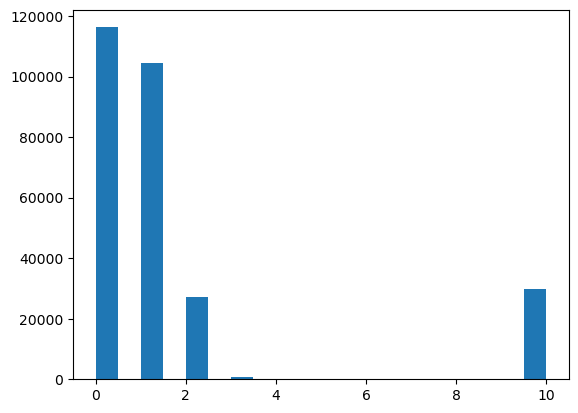

In [21]:
plt.hist(rundata["mc"]["interaction"], 20)

## Extras

In [27]:
RUNstr = ""       #Make an empty string
for run in RUN:
    RUNstr = RUNstr + run
print(RUNstr)

#NUMU Selection
#NUMUSEL1SH = NUMUSEL + ' and n_showers_contained == 1'

3


## Code to get Data files for Plots

In [6]:
# DO NOT RUN IN JUPYTER
#for key, df in rundata.items():
#    if key != 'data':
#        df.to_csv(f'/exp/uboone/data/users/jbtyler1/PELEE/{key}.csv')
print('Hi :)')

Hi :)


## Actual Code to Plot Things

In [24]:
for key, df in rundata.items():
    if key!='data':        
        df['shr_energy_cali'] = df['shr_energy_cali'] * 1/0.83

('interaction', 10, (0, 10), 'Interaction ID')


../../microfit/run_plotter.py:119: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


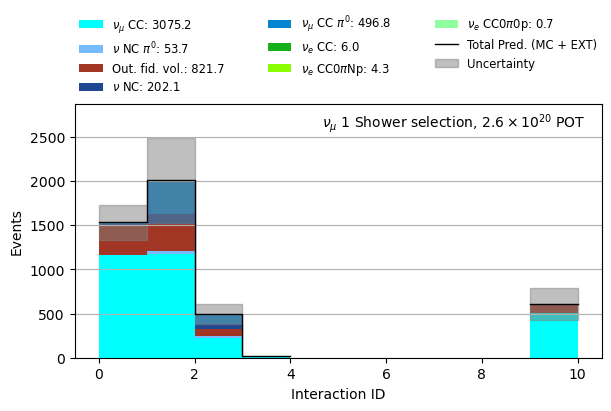

In [31]:
preselection = "NUMU"
selection = "NUMU1SHTOT"

for binning_def in vdef.OLEE_variables:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes1 = plotter.plot(
        category_column="category",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )
    
    plt.savefig(f'Plots/Research/{preselection}_{selection}_Run{RUNstr}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.savefig(f'Plots/Research/{preselection}_{selection}_Run{RUNstr}_{binning_def[0]}.png', bbox_inches='tight')
    plt.show()

#     axes2 = plotter.plot(
#         category_column="interaction",
#         include_multisim_errors=True,
#         add_ext_error_floor=False,
#         show_data_mc_ratio=False,
#         show_chi_square=False,
#     )

#     plt.savefig(f'plots/reco_study/int_{preselection}_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
#     plt.show()